In [251]:
import sys, os
sys.path.append('..')
import utils.io as io
from matplotlib import pyplot as plt
import numpy as np
import src.observables as obs
DATADIR = '../../data/iDMRG/'
from scipy.fftpack import fft, ifft, fftfreq, fftshift

In [252]:
# psi, results = io.load_mps_with_metadata('lastVpm_3.800_chi500.h5')
# psi, results = io.load_mps_with_metadata('ff_chi80.h5')
loadfile = os.path.join(DATADIR, "Vpm3.8cc/Vpm_3.800_chi1000.h5")
# loadfile = os.path.join(DATADIR, 'ffcc/ff_chi500.h5')
psi, results = io.load_mps_with_metadata(loadfile)
print('Correlation length = ', psi.correlation_length2())
diags = results["diagnostics"]
diags.keys()

Correlation length =  185.79622073719838


dict_keys(['Delta_E', 'Delta_S', 'E', 'N_updates', 'S', 'max_E_trunc', 'max_S', 'max_chi', 'max_trunc_err', 'norm_err', 'sweep', 'time'])

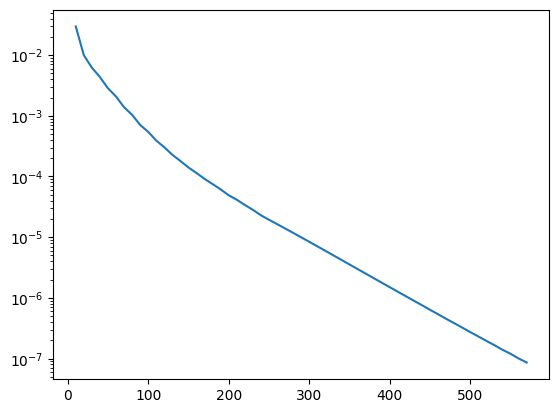

In [253]:
plt.plot(diags['sweep'], np.abs(diags['Delta_S']))
plt.yscale('log')

In [259]:
distrange = 200 #picked smaller than correlation length
chargecorr = obs.denoise_rolling(np.abs(obs.charge_corr(psi, distrange, connected=True)), window=1)
spinzcorr = obs.denoise_rolling(np.abs(obs.SzSz_corr(psi, distrange, connected=True)), window=1)
spinpmcorr = obs.denoise_rolling(np.abs(obs.SpSm_corr(psi, distrange)), window=1)
electroncorr = obs.denoise_rolling(np.abs(obs.electron_corr(psi, distrange, "tot")), window=1)

0.46291663111095777


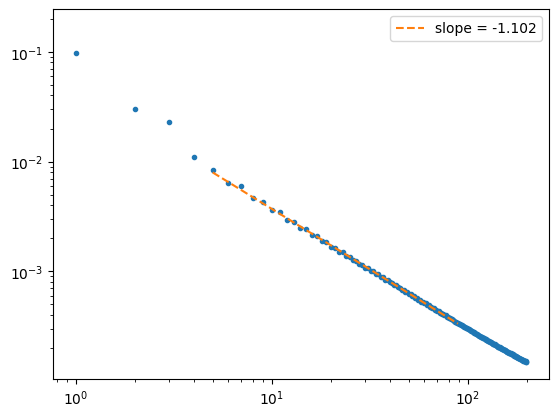

In [293]:
xvals = np.arange(distrange)
# yvals = obs.denoise_rolling(np.abs(alt_spinzcorr), window=1)
yvals = obs.denoise_rolling(np.abs(alt_spinpmcorr), window=2)
# yvals = np.abs(obs.SzSz_corr(psi, 100, connected=True))
plt.plot(xvals, yvals,ls='', marker='.')
fitw = slice(5, 90)
m, logc = np.polyfit(np.log(xvals[fitw]), np.log(yvals[fitw]), 1)
plt.plot(xvals[fitw], np.exp(logc) * xvals[fitw]**m, ls='--', label=f'slope = {m:.3f}')
# vibes = 0.07 * xvals**(-1 - 0.7126) * np.abs(np.log(xvals))**0.5
# plt.plot(vibes)
plt.yscale('log')
plt.xscale('log')
plt.legend()

Kc = np.pi**2 * np.exp(logc)
print(Kc)

In [271]:
KDEF = 0.7125953383210929
0.25*(KDEF + 1/KDEF + 2)

1.028979083609142

In [258]:
print(psi.expectation_value('Sx'))
psi.expectation_value('Sz'), 0.5 * (psi.expectation_value('Nu') - psi.expectation_value('Nd'))

[-0.00757226 -0.0146719   0.00757225  0.01467191]


(array([-2.69691434e-11, -2.85089389e-11, -2.82426792e-11, -2.75926248e-11]),
 array([-2.69691491e-11, -2.85089313e-11, -2.82426582e-11, -2.75926226e-11]))

/scratch/ashankar/Spin1LongRangeOrder.jl/python/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/scratch/ashankar/Spin1LongRangeOrder.jl/python/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


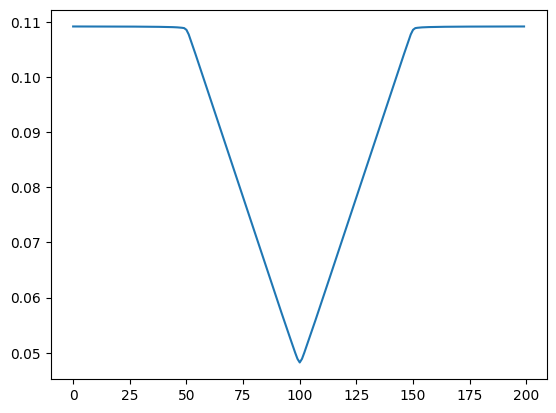

In [244]:
plt.plot(fftshift(fft(obs.SzSz_corr(psi, 200, connected=False))))

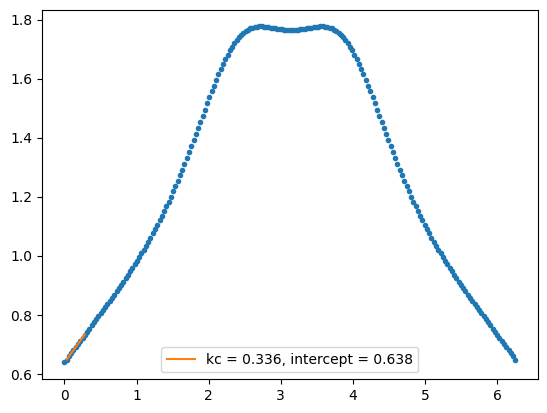

In [257]:
fitrange = 200
corrvals = alt_chargecorr[0:fitrange]
# _, corrvals = connected_charge_correlations_avg(psi, fitrange)

kvals = (2*np.pi/ fitrange )* np.arange(fitrange)
Sc_k = (1.) * np.array([np.sum(np.exp(1j * kval * np.arange(fitrange)) * corrvals[0:fitrange]) for kval in kvals])
plt.plot(kvals, np.real(np.pi * Sc_k), ls='', marker='.')

fftfitwin = slice(1, 10)
xfit, yfit = np.array(kvals[fftfitwin]), np.array(np.pi*np.real(Sc_k[fftfitwin]))
kc, intercept = np.polyfit(xfit, yfit, 1)
plt.plot(xfit, kc * xfit + intercept, label=f'kc = {kc:.3f}, intercept = {intercept:.3f}')
plt.legend()

In [256]:
psi.expectation_value('Ntot')

array([0.50000643, 0.49999357, 0.50000652, 0.49999348])

In [185]:
def connected_charge_correlations_avg(psi, length):
    """
    Connected density-density correlations averaged over the unit cell.
    """
    L = psi.L
    n = psi.expectation_value("Ntot")

    C = np.zeros(length)

    for i in range(L):
        nn = psi.correlation_function(
            "Ntot", "Ntot",
            sites1=[i],
            sites2=list(range(i, i + length))
        )[0]

        nj = np.array([n[(i + r) % L] for r in range(length)])
        C += nn - n[i] * nj

    C /= L
    return np.arange(length), C

def connected_sz_correlations_avg(psi, length):
    """
    Connected spin-spin correlations

        C(r) = <Sz_i Sz_j> - <Sz_i><Sz_j>

    averaged over the unit cell.
    """
    L = psi.L
    sz = psi.expectation_value("Sz")

    C = np.zeros(length)

    for i in range(L):
        ssz = psi.correlation_function(
            "Sz", "Sz",
            sites1=[i],
            sites2=list(range(i, i + length))
        )[0]

        szj = np.array([sz[(i + r) % L] for r in range(length)])
        C += ssz - sz[i] * szj

    C /= L
    return np.arange(length), C


def sp_sm_correlations_avg(psi, length):
    """
    Transverse spin correlations

        <S+_i S-_j>

    averaged over the unit cell.
    """
    L = psi.L

    C = np.zeros(length, dtype=complex)

    for i in range(L):
        corr = psi.correlation_function(
            "Sp", "Sm",
            sites1=[i],
            sites2=list(range(i, i + length))
        )[0]

        C += corr

    C /= L
    return np.arange(length), C


def green_function_up_avg(psi, length):
    """
    Spin-up single-particle Green's function

        G(r) = <Cd_up(i) C_up(j)>

    averaged over the unit cell.
    """
    L = psi.L

    G = np.zeros(length, dtype=complex)

    for i in range(L):
        corr = psi.correlation_function(
            "Cdu", "Cu",
            sites1=[i],
            sites2=list(range(i, i + length))
        )[0]

        G += corr

    G /= L
    return np.arange(length), G


def green_function_down_avg(psi, length):
    """
    Spin-down single-particle Green's function

        G(r) = <Cd_down(i) C_down(j)>
    """
    L = psi.L

    G = np.zeros(length, dtype=complex)

    for i in range(L):
        corr = psi.correlation_function(
            "Cdd", "Cd",
            sites1=[i],
            sites2=list(range(i, i + length))
        )[0]

        G += corr

    G /= L
    return np.arange(length), G

In [255]:
_, alt_chargecorr = connected_charge_correlations_avg(psi, 200)
_, alt_spinzcorr = connected_sz_correlations_avg(psi, 200)
_, alt_spinpmcorr = sp_sm_correlations_avg(psi, 200)
_, alt_electroncorr = green_function_down_avg(psi, 200)